# Fairness in Insurance Pricing

Insurance is, by construction, a business of **risk discrimination**: premiums are deliberately differentiated so that policyholders who bring more expected cost to the pool pay more. The actuarial question is therefore never *"should we distinguish between risks?"* — solidarity through a risk-rated pool requires that we do — but **which distinctions are permissible, and which are unfair?**

The line society draws is between two kinds of differentiation:

- **Direct discrimination** — using a *protected attribute* $S$ (sex, race, ethnicity, sometimes health or disability status) directly as a rating factor.
- **Indirect / proxy discrimination** — using non-protected covariates $X$ (postcode, occupation, car model, a lifestyle flag) that are *correlated* with $S$, so the model can implicitly reconstruct the protected attribute even though it was never an input.

The central, counter-intuitive lesson of this page is that **"fairness through unawareness" — simply deleting $S$ — does not remove discrimination**. Because the remaining covariates still carry information about $S$, an unaware model can keep pricing on the protected attribute through the back door, and in some cases does so *more* opaquely than a model that used $S$ openly. Deciding whether a correlated covariate is a *legitimate risk factor* or a *discriminatory proxy* is not a question the correlation matrix can answer — it is a **causal** question. That is where the machinery from {doc}`../tutorial/2_2_graphical_models` and {doc}`../tutorial/2_3_debias` earns its place.

This notebook makes the fairness concepts from {doc}`../tutorial/2_3_debias` — {prf:ref}`proxy-discrimination`, {prf:ref}`fairness-unawareness`, {prf:ref}`discrimination-free-pricing`, {prf:ref}`counterfactual-fairness` and the {prf:ref}`group-fairness-criteria` — concrete on a synthetic insurance portfolio. The treatment of the three prices follows [Lindholm, Richman, Tsanakas & Wüthrich (2022)](https://arxiv.org/abs/2209.00858), the canonical actuarial reference; the comparison of statistical fairness definitions follows the [Google PAIR *Measuring Fairness* explorable (2020)](https://pair.withgoogle.com/explorables/measuring-fairness/) and the impossibility result of [Chouldechova (2017)](https://doi.org/10.1089/big.2016.0047).

**Road map**

1. **Frame the tension** — why risk classification is discriminatory by design, and what makes a distinction *unfair*.
2. **Map the protected attribute onto a DAG** — classify each pathway as fair (legitimate risk) or unfair (direct / proxy).
3. **The three prices** — best-estimate, unawareness, and *discrimination-free* — and why unawareness leaks ({prf:ref}`alg-discfree-price`).
4. **An applied example** — build a portfolio, price it three ways, and watch proxy discrimination appear and then be removed.
5. **Counterfactual fairness and path-specific effects** — the causal reading of "would this price change if the policyholder's group were different?"
6. **Statistical vs causal fairness** — the group-fairness criteria, their mutual incompatibility, and what regulation requires.


## Setup

We use a small, self-contained toolkit: `scikit-learn` for the pricing models, `scipy` for the logistic link, and the `draw_causal_graph_svg` helper from `utils.py` to render the fairness DAG as a crisp vector figure (the same helper used in {doc}`observational_data`).


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from IPython.display import SVG, display

from utils import draw_causal_graph_svg

# Hide benign numerical RuntimeWarnings from sklearn's solvers (overflow/divide
# in intermediate matmuls) so the rendered page stays clean.
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(all="ignore")  # NumPy floating-point warnings (divide/overflow/invalid)

rng = np.random.default_rng(7)

FIG_DIR = "figs"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

# Consistent colours for the two protected groups throughout the notebook.
SEX_COLORS = {"Female": "#e377c2", "Male": "#1f77b4"}


## When is risk classification *discrimination*?

A premium is a price for expected risk. Charging a 70-year-old more than a 30-year-old for life cover is differentiation that virtually everyone accepts, because age is a genuine, causal driver of mortality. Charging a woman more than an otherwise-identical man for the *same* cover — purely because of her sex — is differentiation that most legal systems now **prohibit**. The difference is not statistical strength (sex can be a very strong predictor); it is a societal judgement that some characteristics must not be priced on, even when they are predictive.

This judgement is encoded in regulation:

- **EU — sex.** The Gender Directive (2004/113/EC), as interpreted by the Court of Justice in the *Test-Achats* ruling ([C-236/09](https://curia.europa.eu/juris/liste.jsf?num=C-236/09), effective 21 December 2012), requires **unisex pricing**: sex may not be used as a rating factor that produces differences in individual premiums or benefits.
- **EU — AI systems.** Under the EU AI Act ([Regulation (EU) 2024/1689](https://eur-lex.europa.eu/eli/reg/2024/1689/oj)), AI systems used for **risk assessment and pricing in life and health insurance** are classified as *high-risk*, triggering obligations on data governance, transparency and bias monitoring.
- **Switzerland (the SAV context).** Switzerland is outside the EU, and sex-differentiated tariffs have historically been permitted in private insurance; supervision focuses on actuarial justification and the revised Federal Act on Data Protection (nFADP, in force 2023). The direction of travel — scrutiny of proxy discrimination in algorithmic pricing — nonetheless mirrors the EU debate.

```{warning}
Regulation in this area moves quickly and differs by line of business and jurisdiction. The specifics above are orientation, not legal advice — **verify the current rules** for your market and product before relying on them.
```

The actuarial problem this creates is precise: we must build a price that is **predictive of risk** yet **free of (direct and indirect) dependence on the protected attribute** $S$. Deleting $S$ is necessary but, as we now show, far from sufficient.


### Mapping the protected attribute onto the DAG

Whether a covariate is a *legitimate risk factor* or a *discriminatory proxy* depends on the **causal structure**, not on how strongly it correlates with $S$. We therefore start, as always, by drawing the graph ({doc}`../tutorial/2_2_graphical_models`) and labelling every pathway from the protected attribute $S$ to the claim $Y$.

In the portfolio below there are three covariates and three pathways:

| Pathway | Type | Verdict |
|---|---|---|
| $S \rightarrow Y$ | **Direct** effect of the protected attribute on claims | Unfair — direct discrimination |
| $S \rightarrow \text{Proxy} \rightarrow Y$ | **Indirect** effect through a non-protected covariate correlated with $S$ | Disputed — *proxy* discrimination if the covariate is judged a mere stand-in for $S$ |
| $\text{Age} \rightarrow Y$ | A risk factor **independent of $S$** | Fair — legitimate risk classification |

The colours below follow the DAG palette from the tutorial: the **sensitive** node $S$ is highlighted, dashed-red edges mark the channels that transmit protected information to the price, and solid edges mark causal effects we are happy to price on. The art of fair pricing is to keep the legitimate (solid) paths and close the discriminatory (dashed) ones.


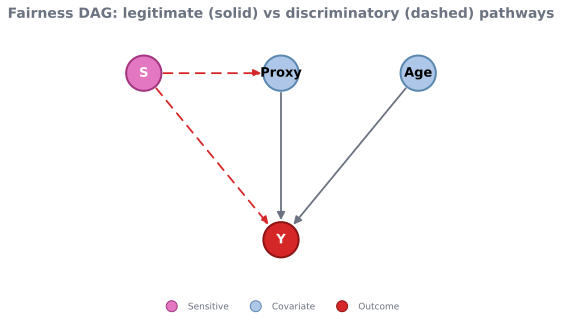

In [2]:
# Fairness DAG: S is the protected attribute; the dashed-red edges are the
# channels (direct + proxy) through which S can leak into the price.
positions = {
    "S":     (0.0, 2.0),   # protected attribute (sex)
    "Proxy": (1.4, 2.0),   # non-protected covariate correlated with S (lifestyle flag)
    "Age":   (2.8, 2.0),   # legitimate risk factor, independent of S
    "Y":     (1.4, 0.3),   # claim cost
}
edges = [
    ("S", "Proxy", "biasing"),   # S shapes the proxy            -> indirect channel
    ("S", "Y",     "biasing"),   # direct effect of S on claims  -> direct discrimination
    ("Proxy", "Y", "causal"),    # proxy affects claims
    ("Age", "Y",   "causal"),    # legitimate risk factor
]
node_styles = {"S": "sensitive", "Proxy": "covariate", "Age": "covariate", "Y": "outcome"}

svg_path = draw_causal_graph_svg(
    edges=edges,
    positions=positions,
    node_styles=node_styles,
    filepath=os.path.join(FIG_DIR, "dag_fairness.svg"),
    title="Fairness DAG: legitimate (solid) vs discriminatory (dashed) pathways",
    legend_types=["sensitive", "covariate", "outcome"],
)
display(SVG(svg_path))


## Three prices, three notions of fairness

Let $Y$ be the claim cost, $X$ the vector of **non-protected** covariates, and $S$ the protected attribute. [Lindholm et al. (2022)](https://arxiv.org/abs/2209.00858) compare three candidate prices.

```{prf:definition} Best-estimate price
:label: best-estimate-price

The **best-estimate price** is the full conditional expectation, using *every* covariate including the protected attribute:

$$
\mu(x, s) = \mathbb{E}[Y \mid X = x,\, S = s].
$$

It is the most accurate price, but it discriminates **directly** — two policyholders identical in $X$ are charged differently because of $S$.
```

```{prf:definition} Unawareness price
:label: unawareness-price

The **unawareness price** drops the protected attribute and conditions on $X$ only:

$$
\mu(x) = \mathbb{E}[Y \mid X = x] = \sum_{s} \mu(x, s)\, \underbrace{P(S = s \mid X = x)}_{\text{conditional}}.
$$

It satisfies {prf:ref}`fairness-unawareness`, yet the tower property shows it is a **weighted average of the best-estimate price using the conditional $P(S \mid X)$** — exactly the term that lets $X$ *infer* $S$. Whenever $X$ and $S$ are dependent, the unawareness price still channels protected information: this is {prf:ref}`proxy-discrimination`.
```

```{prf:definition} Discrimination-free price
:label: discrimination-free-price-app

The **discrimination-free price** ([Lindholm et al., 2022](https://arxiv.org/abs/2209.00858)) averages the best-estimate price over a **marginal** distribution $P^{*}(S)$ that does *not* depend on $x$:

$$
h(x) = \sum_{s} \mu(x, s)\, P^{*}(S = s).
$$

By replacing the conditional $P(S \mid X)$ with a fixed marginal $P^{*}(S)$, it severs the inference channel: $h$ depends on $x$ only, and no longer uses $X$ to deduce $S$. It is the actuarial realisation of {prf:ref}`discrimination-free-pricing`.
```

The contrast that matters is the **weighting**: the unawareness price weights $\mu(x,s)$ by the *conditional* $P(S\mid X)$ (which encodes how much $X$ reveals about $S$), whereas the discrimination-free price weights by a *marginal* $P^{*}(S)$ (which reveals nothing). Their difference,

$$
\mu(x) - h(x) = \sum_s \mu(x,s)\,\bigl[P(S = s \mid X = x) - P^{*}(S = s)\bigr],
$$

is precisely the **inference / proxy component** baked into the unawareness price.

```{prf:algorithm} Discrimination-Free Pricing
:label: alg-discfree-price
:class: dropdown

**Inputs** Data $D = \{(X_i, S_i, Y_i)\}_{i=1}^{n}$, ML learner $\mathcal{L}$, reference marginal $P^{*}(S)$

**Outputs** Discrimination-free price $h(x)$

1. Fit the best-estimate model $\hat{\mu}(x, s) = \mathcal{L}(Y \sim X, S)$ on $D$ *(this step uses the protected $S$)*
2. Choose a reference marginal $P^{*}(S)$ — e.g. the portfolio proportions $P^{*}(S = s) = \frac{1}{n}\sum_i \mathbb{1}\{S_i = s\}$, independent of $x$
3. For every policyholder $i$ and each level $s$, predict the counterfactual claim cost $\hat{\mu}(x_i, s)$
4. Average over the **marginal**, not the conditional: $h(x_i) = \sum_{s} \hat{\mu}(x_i, s)\, P^{*}(S = s)$
5. Return $h(x_i)$ *(a function of $x$ alone — the $X \to S$ inference channel is removed)*
```

Note that the algorithm still needs $S$ *at training time* (to fit $\hat\mu(x,s)$ and predict at each level of $s$). This is the crucial practical twist: **you must collect the protected attribute in order to neutralise it**. An organisation that never records $S$ cannot build a discrimination-free price and is stuck with the leaky unawareness price.

## A synthetic health-insurance portfolio

To make the three prices tangible we simulate a health-insurance book where the data-generating process is known, so we can check the prices against ground truth. Each of $N = 6000$ policyholders has:

- **`sex`** ($S \in \{0, 1\}$, $1 =$ male) — the **protected** attribute, roughly balanced across the book;
- **`age`** — a **legitimate** risk factor, drawn independently of $S$, so any premium difference it creates between the sexes is incidental;
- **`lifestyle`** — a non-protected **proxy** flag (think of a high-risk-occupation or lifestyle indicator) that is *statistically dependent on $S$*: males carry it about twice as often;
- **`claims`** — the annual claim cost, with Gamma noise around a mean that rises with age, with the lifestyle flag, **and directly with sex** (a genuine morbidity difference).

The direct $S \rightarrow Y$ edge is what makes the unawareness price leak: because `lifestyle` predicts `sex`, dropping `sex` does not stop the model from re-deriving the male morbidity loading through the proxy.


In [3]:
N = 6000

# Protected attribute S: sex (0 = female, 1 = male), a roughly balanced book.
S = rng.binomial(1, 0.5, size=N)

# Legitimate risk factor: age, drawn INDEPENDENTLY of S.
age = rng.normal(45, 12, size=N).clip(18, 80)

# Proxy covariate: a non-protected lifestyle flag that depends on S. We keep the
# structural noise U_life explicit so we can compute clean counterfactuals later.
U_life = rng.uniform(size=N)
lifestyle = (U_life < expit(-0.6 + 1.4 * S)).astype(int)   # P(flag | S): F ~ 35%, M ~ 69%

# True expected annual claim cost: rises with age, with the lifestyle flag, and
# DIRECTLY with sex (a genuine morbidity loading -> the S -> Y edge).
base = 800.0
mu_true = base * np.exp(
    0.020 * (age - 45)   # legitimate age gradient
    + 0.55 * lifestyle   # lifestyle risk
    + 0.25 * S           # direct effect of sex on claims
)

# Observed claims: positive, right-skewed Gamma costs around the mean.
shape_k = 2.0
claims = rng.gamma(shape_k, mu_true / shape_k)

df = pd.DataFrame({"age": age, "lifestyle": lifestyle, "sex": S, "claims": claims})

print(
    f"Portfolio: {N} policyholders | male share = {S.mean():.0%} | "
    f"lifestyle-flag rate -> female {lifestyle[S == 0].mean():.0%}, "
    f"male {lifestyle[S == 1].mean():.0%}"
)
df.head()


Portfolio: 6000 policyholders | male share = 49% | lifestyle-flag rate -> female 34%, male 68%


,age,lifestyle,sex,claims
0,65.187465,1,1,3055.631711
1,45.926668,0,1,1338.411916
2,41.353530,0,1,306.187224
3,42.372466,0,0,970.628693
4,42.798343,1,0,1124.842408


### Fitting the three prices

We follow {prf:ref}`alg-discfree-price`. A gradient-boosting model estimates the best-estimate price $\hat\mu(x,s)$ from **all** covariates. We then predict each policyholder's cost at *both* sexes, holding the covariates fixed, and combine those two predictions in two different ways:

- the **unawareness** price weights them by the conditional $\hat P(S\mid X)$, obtained from a logistic model of `sex` on the covariates — this is the inference channel;
- the **discrimination-free** price weights them by the fixed marginal $P^{*}(S)$ (the portfolio sex split).

In [4]:
FEAT_FULL = ["age", "lifestyle", "sex"]
FEAT_X = ["age", "lifestyle"]

# 1. Best-estimate model mu(x, s): uses the protected attribute.
m_full = GradientBoostingRegressor(
    max_depth=3, n_estimators=300, learning_rate=0.05, random_state=0
)
m_full.fit(df[FEAT_FULL], df["claims"])

# Predict the claim cost at BOTH sexes, holding the covariates fixed.
mu1 = m_full.predict(df[FEAT_X].assign(sex=1)[FEAT_FULL])   # mu(x, S=male)
mu0 = m_full.predict(df[FEAT_X].assign(sex=0)[FEAT_FULL])   # mu(x, S=female)

# 2. P(S = male | X): the inference channel the proxy opens up.
clf_s = LogisticRegression().fit(df[FEAT_X], df["sex"])
ps_x = clf_s.predict_proba(df[FEAT_X])[:, 1]

# 3. The three prices (same mu's, different weighting of S).
pS1 = df["sex"].mean()                                       # marginal P*(S = male)
price_best = np.where(df["sex"].values == 1, mu1, mu0)       # uses the realised S
price_unaware = ps_x * mu1 + (1 - ps_x) * mu0               # weights by CONDITIONAL P(S|X)
price_disc_free = pS1 * mu1 + (1 - pS1) * mu0               # weights by MARGINAL P*(S)

df["price_best"] = price_best
df["price_unaware"] = price_unaware
df["price_disc_free"] = price_disc_free

# Average premium gap between the sexes under each price.
print("Mean price gap (male - female):")
for col, lab in zip(
    ["price_best", "price_unaware", "price_disc_free"],
    ["Best-estimate", "Unawareness", "Discrimination-free"],
):
    gap = df.loc[df.sex == 1, col].mean() - df.loc[df.sex == 0, col].mean()
    print(f"  {lab:>22s}: {gap:8.1f}")


Mean price gap (male - female):
           Best-estimate:    561.0
             Unawareness:    275.4
     Discrimination-free:    238.3


### Reading the result: the proxy "inference surcharge"

The printed gaps fall in a telling order: **best-estimate > unawareness > discrimination-free**.

- The **best-estimate** gap is the largest — it contains the direct sex loading *and* the lifestyle difference.
- The **unawareness** gap shrinks but does **not** vanish: even though `sex` was deleted, the model rebuilds part of the loading by inferring sex from `lifestyle`. This residual is the proxy discrimination.
- The **discrimination-free** gap is smaller still — what remains reflects only the legitimate variation in $X$, priced through the fixed marginal weighting.

The left panel below contrasts the average premium by sex under each price. The right panel isolates the inference surcharge $\mu(x) - h(x)$ (unawareness minus discrimination-free): it is **positive for the lifestyle-flagged group** (predominantly male, so the unawareness price reads the flag as a signal of higher male morbidity and adds a loading) and **negative for the unflagged group**. That sign pattern *is* proxy discrimination — a sex loading applied via a non-protected variable.


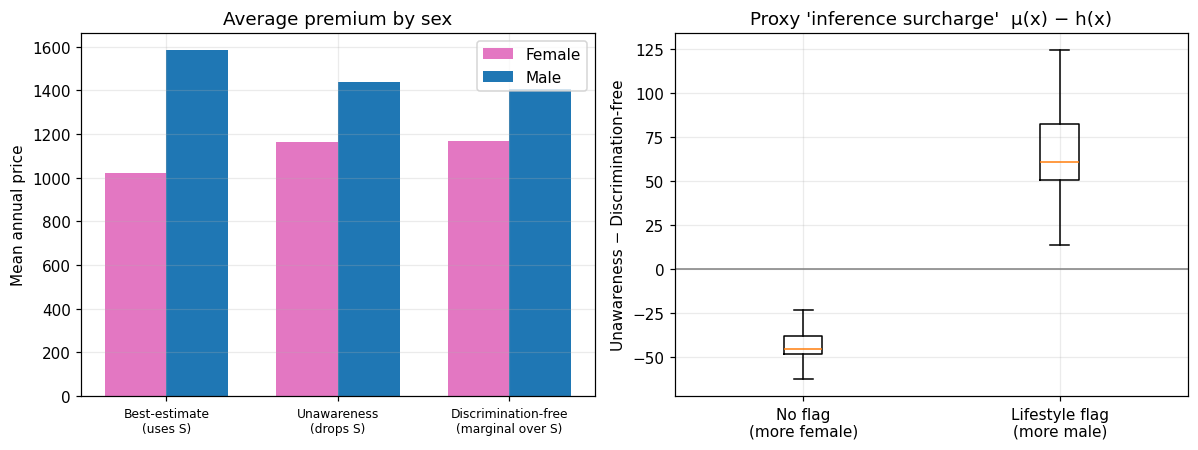

In [5]:
methods = ["price_best", "price_unaware", "price_disc_free"]
labels = ["Best-estimate\n(uses S)", "Unawareness\n(drops S)", "Discrimination-free\n(marginal over S)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Left: mean premium by sex under each price.
x = np.arange(len(methods))
w = 0.36
f_means = [df.loc[df.sex == 0, m].mean() for m in methods]
m_means = [df.loc[df.sex == 1, m].mean() for m in methods]
axes[0].bar(x - w / 2, f_means, w, label="Female", color=SEX_COLORS["Female"])
axes[0].bar(x + w / 2, m_means, w, label="Male", color=SEX_COLORS["Male"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel("Mean annual price")
axes[0].set_title("Average premium by sex")
axes[0].legend()

# Right: the inference surcharge, split by the proxy flag.
surcharge = df["price_unaware"] - df["price_disc_free"]
axes[1].boxplot(
    [surcharge[df.lifestyle == 0], surcharge[df.lifestyle == 1]], showfliers=False
)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["No flag\n(more female)", "Lifestyle flag\n(more male)"])
axes[1].axhline(0, color="grey", lw=1)
axes[1].set_ylabel("Unawareness − Discrimination-free")
axes[1].set_title("Proxy 'inference surcharge'  μ(x) − h(x)")

plt.tight_layout()
plt.show()


## From statistical to causal fairness: counterfactuals and path-specific effects

The discrimination-free price answers an *associational* question — it removes the $X \to S$ inference channel. But it still prices on `lifestyle`, and we have not yet asked the genuinely causal question: **is the $S \rightarrow \text{lifestyle} \rightarrow Y$ path a legitimate risk pathway, or proxy discrimination we should also remove?** Answering that requires a model of *counterfactuals*, not just conditional expectations.

{prf:ref}`counterfactual-fairness` ([Kusner et al., 2017](https://arxiv.org/abs/1703.06856)) formalises it: a price is counterfactually fair if it would be **unchanged in the world where the policyholder's protected attribute had been different**, with everything that descends from $S$ propagated accordingly. Computing such a counterfactual is the three-step recipe from {doc}`../tutorial/2_3_debias`: *abduction* (recover the structural noise — here `U_life`), *action* (set $S \leftarrow 1 - S$), *prediction* (recompute the descendants).

This exposes a trap. Consider two ways of "flipping the sex":

1. **Naive flip** — change $S$ but leave the covariates untouched. The unawareness price never reads $S$, so it is **unchanged** — it looks counterfactually fair.
2. **Full flip** — change $S$ *and* propagate it through its descendant `lifestyle` (using the fixed noise `U_life`). Now the proxy moves, and so does the unawareness price.

The gap between (1) and (2) is exactly the **path-specific effect** of $S$ through the proxy. A fairness audit that only does the naive flip would certify a discriminatory price as fair.


In [6]:
# Counterfactual sex, holding the structural noise U_life fixed (abduction-action-prediction).
S_cf = 1 - df["sex"].values
life_cf = (U_life < expit(-0.6 + 1.4 * S_cf)).astype(int)   # proxy propagated to the new sex

# (1) NAIVE flip: change S only, leave covariates as observed.
#     Best-estimate reads S directly -> it moves. Unawareness ignores S -> unchanged.
price_best_naive = np.where(S_cf == 1, mu1, mu0)
delta_best_naive = price_best_naive - df["price_best"].values
delta_unaware_naive = np.zeros(N)   # unawareness price does not depend on S at all

# (2) FULL flip: propagate S through the proxy `lifestyle`, then re-price.
Xcf = pd.DataFrame({"age": df["age"].values, "lifestyle": life_cf})
ps_x_cf = clf_s.predict_proba(Xcf[FEAT_X])[:, 1]
mu1_cf = m_full.predict(Xcf.assign(sex=1)[FEAT_FULL])
mu0_cf = m_full.predict(Xcf.assign(sex=0)[FEAT_FULL])
price_unaware_full = ps_x_cf * mu1_cf + (1 - ps_x_cf) * mu0_cf
delta_unaware_full = price_unaware_full - df["price_unaware"].values

print("Mean absolute change in price when we flip the protected attribute:")
print(f"  Best-estimate, naive flip (S only)          : {np.abs(delta_best_naive).mean():7.1f}")
print(f"  Unawareness,   naive flip (S only)          : {np.abs(delta_unaware_naive).mean():7.1f}  <- looks 'fair'")
print(f"  Unawareness,   full flip (S -> proxy -> Y)  : {np.abs(delta_unaware_full).mean():7.1f}  <- path-specific leak revealed")


Mean absolute change in price when we flip the protected attribute:
  Best-estimate, naive flip (S only)          :   323.3
  Unawareness,   naive flip (S only)          :     0.0  <- looks 'fair'
  Unawareness,   full flip (S -> proxy -> Y)  :   255.4  <- path-specific leak revealed


## Why you cannot satisfy every fairness definition at once

It is tempting to ask for a price that is fair by *every* statistical yardstick — equal acceptance rates, equal error rates, and equal predictive accuracy across groups. The [Google PAIR "Measuring Fairness" explorable](https://pair.withgoogle.com/explorables/measuring-fairness/) shows visually why this is impossible whenever the groups have **different base rates**, and the result is made precise by the impossibility theorems of [Kleinberg, Mullainathan & Raghavan (2017)](https://arxiv.org/abs/1609.05807) and [Chouldechova (2017)](https://arxiv.org/abs/1703.00056): except in degenerate cases, **calibration and equalised error rates cannot both hold**.

To see it on our portfolio, recast pricing as a binary decision — flag the costliest policyholders (top 20% of claims) for a manual underwriting review, using the discrimination-free price as the score — and compute the classic group-fairness diagnostics ({prf:ref}`group-fairness-criteria`):

- **Selection rate** — share flagged in each group (*demographic / statistical parity*);
- **TPR / recall** — of the truly high-cost, the share flagged (*equal opportunity*, [Hardt et al., 2016](https://arxiv.org/abs/1610.02413));
- **PPV / precision** — of those flagged, the share truly high-cost (*predictive parity / calibration*).


In [7]:
# Binary decision: flag the costliest policyholders for review.
high_cost = (df["claims"] > np.quantile(df["claims"], 0.80)).astype(int)
score = df["price_disc_free"].values
flagged = (score > np.quantile(score, 0.80)).astype(int)

df["high_cost"], df["flagged"] = high_cost, flagged


def group_metrics(g):
    sub = df[df.sex == g]
    base = sub["high_cost"].mean()                          # base rate
    sel = sub["flagged"].mean()                             # selection rate (demographic parity)
    tpr = sub.loc[sub.high_cost == 1, "flagged"].mean()     # equal opportunity
    ppv = sub.loc[sub.flagged == 1, "high_cost"].mean()     # predictive parity
    return base, sel, tpr, ppv


fair_tbl = pd.DataFrame(
    [(name, *group_metrics(g)) for g, name in [(0, "Female"), (1, "Male")]],
    columns=["Group", "Base rate", "Selection rate", "TPR (equal opp.)", "PPV (calibration)"],
).set_index("Group")

print("Different base rates -> the fairness criteria below cannot all be equalised at once:\n")
fair_tbl.round(3)


Different base rates -> the fairness criteria below cannot all be equalised at once:



,Base rate,Selection rate,TPR (equal opp.),PPV (calibration)
Group,,,,
Female,0.115,0.135,0.433,0.369
Male,0.288,0.261,0.499,0.551


Males have the higher base rate of high claims (the direct morbidity loading plus the proxy), so a single score threshold cannot equalise the selection rate, the TPR **and** the PPV simultaneously — pushing two into balance throws the third out. This is the actuarial face of the impossibility theorem: **"fair" is not one property to optimise but a menu of mutually incompatible ones, and choosing among them is a value judgement, not a statistical one.**

### A map of the fairness definitions

| Definition | Type | What it requires | What it misses |
|---|---|---|---|
| **Fairness through unawareness** | Statistical | Do not use $S$ as an input | Proxy discrimination via $X$ |
| **Demographic / statistical parity** | Statistical | Equal selection rate across groups | Ignores genuine risk differences; hurts accuracy |
| **Equalised odds / equal opportunity** | Statistical | Equal error rates across groups | Incompatible with calibration at unequal base rates |
| **Predictive parity / calibration** | Statistical | Score means the same thing across groups | Incompatible with equal error rates |
| **Discrimination-free price** (Lindholm et al.) | Causal-ish | Average $\mu(x,s)$ over a marginal $P^{*}(S)$ | Still prices on proxy *paths* through $X$ |
| **Counterfactual fairness** (Kusner et al.) | Causal | Price invariant to flipping $S$ and its descendants | Needs a (partly untestable) causal model |

The lesson of {doc}`../tutorial/2_3_debias` returns here in applied form: the **statistical** definitions disagree with one another and none of them, on its own, captures "this price does not discriminate." Only by drawing the DAG and naming which **paths** from $S$ to $Y$ are legitimate can an actuary state precisely what fairness means for a given product — and the discrimination-free price plus a path-specific / counterfactual audit operationalises that choice.

### Interactive: prices vs. fairness measures

The explainer below puts the two choices side by side on one simulated portfolio. Pick a **price approach** (best-estimate, unawareness, or discrimination-free) and a **fairness measure** (group unaware, demographic parity, equal opportunity, equal accuracy), and watch the consequences:

- the **premium gap** between the sexes and the **proxy leakage** ($\mu(x) - h(x)$) react to the approach and to the *proxy-strength* slider — turn the proxy up and the unawareness price leaks more;
- the selected **fairness measure** is judged *fair* or *unfair* for that approach;
- the **all-measures panel** shows that no single price satisfies every criterion at once — switching the approach trades one violation for another. Press **New portfolio** to redraw the data.

```{raw} html
<iframe id="fair-price" src="../figure/fairness_price_explainer.html?v=20260610d"
        style="width:100%; border:none; height:1400px;"
        title="Fairness pricing interactive explainer"></iframe>
<script>
(function () {
  var iframe = document.getElementById('fair-price');

  function currentTheme() {
    var root = document.documentElement;
    var theme = root.getAttribute('data-theme');
    if (theme === 'light' || theme === 'dark') return theme;
    var mode = root.getAttribute('data-mode') || 'auto';
    if (mode === 'light' || mode === 'dark') return mode;
    return window.matchMedia('(prefers-color-scheme: dark)').matches ? 'dark' : 'light';
  }
  function sendTheme() {
    if (iframe && iframe.contentWindow) {
      iframe.contentWindow.postMessage({ type: 'set-theme', value: currentTheme() }, '*');
    }
  }

  window.addEventListener('message', function (e) {
    if (!e.data) return;
    if (e.data.type === 'fair-price-height') {
      iframe.style.height = (e.data.height + 20) + 'px';
    } else if (e.data.type === 'fair-price-ready') {
      sendTheme();
    }
  });

  new MutationObserver(sendTheme).observe(document.documentElement, {
    attributes: true, attributeFilter: ['data-mode', 'data-theme']
  });
  window.matchMedia('(prefers-color-scheme: dark)').addEventListener('change', sendTheme);

  iframe.addEventListener('load', sendTheme);
  sendTheme();
})();
</script>
```


## Takeaways for the pricing actuary

```{admonition} A practical workflow for fair pricing
:class: tip

1. **Draw the DAG.** Place the protected attribute $S$, the covariates $X$, and the outcome $Y$, and enumerate every path $S \rightsquigarrow Y$ ({doc}`../tutorial/2_2_graphical_models`).
2. **Classify the paths.** Direct $S \to Y$ effects are off-limits; legitimate factors independent of $S$ are fine; proxy paths $S \to X \to Y$ require an explicit, documented judgement.
3. **Do not rely on unawareness.** Dropping $S$ leaves proxy discrimination intact and may even *hide* it from audit.
4. **Collect $S$ to neutralise $S$.** The discrimination-free price ({prf:ref}`alg-discfree-price`) needs the protected attribute at training time, then averages it out with a marginal $P^{*}(S)$.
5. **Audit causally, not just statistically.** Use a counterfactual / path-specific check to confirm the price would not move if $S$ — and its descendants — had been different.
6. **Pick your fairness criterion deliberately.** The statistical definitions are mutually incompatible at unequal base rates; document which one the product targets and why.
```

**The bottom line.** Insurance must discriminate between *risks*; it must not discriminate on *protected attributes*, directly or by proxy. "Fairness through unawareness" fails because correlated covariates reconstruct the protected attribute. The discrimination-free price of [Lindholm et al. (2022)](https://arxiv.org/abs/2209.00858) gives actuaries a concrete, implementable remedy for the inference channel, and the causal toolkit of this book — DAGs, path-specific effects and {prf:ref}`counterfactual-fairness` — is what lets us decide *which* differences are legitimate in the first place. Fairness is ultimately a causal question dressed as a statistical one.

For the underlying definitions and theory, see {doc}`../tutorial/2_3_debias`; the references are collected in {doc}`../papers/references`.